# RTE7000 OpenSynth (D-GITT-RTE7000-2021) — XIIDM Overview

This notebook inspects a **single XIIDM/IIDM XML snapshot**:

- file metadata (size, hash)
- IIDM schema and network meta
- element counts and structural paths
- basic reference-resolution checks
- sample rows for key equipment types
- presence/absence of injection attributes (loads/generators)

---
#### Bootstrap

In [1]:
from _notebook_bootstrap import bootstrap

repo_root, datasets_root = bootstrap()
repo_root, datasets_root

(PosixPath('/home/user/workspace/datasets-utilities'),
 PosixPath('/home/user/data/datasets'))

---
#### Imports

In [2]:
import pandas as pd

from dataloaders.rte7000_opensynth import Rte7000OpenSynth
from dataset_utils.plotting import bar_counts

---
#### Load dataset object

In [3]:
# Select your file (can be changed to any other snapshot path under datasets_root)
xiidm_relpath = "d_gitt_rte7000_2021/rte-01Jan21-0000.xiidm"

ds = Rte7000OpenSynth(datasets_root=datasets_root, relpath=xiidm_relpath)
ds.path

PosixPath('/home/user/data/datasets/d_gitt_rte7000_2021/rte-01Jan21-0000.xiidm')

---
#### Run sanity pass (with local cache)

In [4]:
from hashlib import sha1

cache_dir = repo_root / ".cache"
cache_dir.mkdir(parents=True, exist_ok=True)

xiidm_path = ds.path
stem = xiidm_path.stem  # rte-01Jan21-0000
suffix = sha1(str(xiidm_path).encode("utf-8")).hexdigest()[:8]
cache_path = cache_dir / f"{stem}_{suffix}_sanity.json"

report = ds.sanity_report(
    samples_per_tag=15,
    max_issue_examples=50,
    path_prefix_depth=3,
    cache_path=cache_path,
    force_recompute=False,
)

cache_path, report["file"], report["iidm"]

(PosixPath('/home/user/workspace/datasets-utilities/.cache/rte-01Jan21-0000_274a9e28_sanity.json'),
 {'path': '/home/user/data/datasets/d_gitt_rte7000_2021/rte-01Jan21-0000.xiidm',
  'size_bytes': 33056020,
  'sha256': '4d5af615aaefb9d72fa7ff6cc9ac38421439bfb06bf9302d009ce0f76992820b'},
 {'root_tag': 'network',
  'namespace': 'http://www.powsybl.org/schema/iidm/equipment/1_12',
  'schema_version_from_namespace': '1_12',
  'network_meta': {'caseDate': '2021-01-01T00:00:00.000+01:00',
   'forecastDistance': '0',
   'id': 'recollement-auto-20210101-0000-enrichi',
   'minimumValidationLevel': 'EQUIPMENT',
   'sourceFormat': 'DIE'}})

---
#### File + IIDM meta

In [5]:
meta = {
    **report["file"],
    **{
        "iidm_namespace": report["iidm"]["namespace"],
        "iidm_schema_version": report["iidm"]["schema_version_from_namespace"],
        **{f"meta_{k}": v for k, v in report["iidm"]["network_meta"].items()},
    },
}
pd.Series(meta)

path                           /home/user/data/datasets/d_gitt_rte7000_202...
size_bytes                                                              33056020
sha256                         4d5af615aaefb9d72fa7ff6cc9ac38421439bfb06bf930...
iidm_namespace                 http://www.powsybl.org/schema/iidm/equipment/1_12
iidm_schema_version                                                         1_12
meta_caseDate                                      2021-01-01T00:00:00.000+01:00
meta_forecastDistance                                                          0
meta_id                                   recollement-auto-20210101-0000-enrichi
meta_minimumValidationLevel                                            EQUIPMENT
meta_sourceFormat                                                            DIE
dtype: object

---
#### Namespaces overview

In [6]:
ns_df = pd.DataFrame(report["counts"]["namespaces_top"])
ns_df.head(20)

,uri,count
0,http://www.powsybl.org/schema/iidm/equipment/1_12,1
1,http://www.powsybl.org/schema/iidm/ext/active_...,1


---
#### Non-IIDM / extension namespaces

In [7]:
report["counts"]["non_iidm_namespaces"]

['http://www.powsybl.org/schema/iidm/ext/active_power_control/1_1']

---
#### Element counts (top 40)

,tag,count
0,switch,85704
1,property,41290
2,step,27436
3,temporaryLimit,20088
4,currentLimits,17077
5,busbarSection,11864
6,point,11268
7,operationalLimitsGroup1,9240
8,operationalLimitsGroup2,7837
9,line,7745


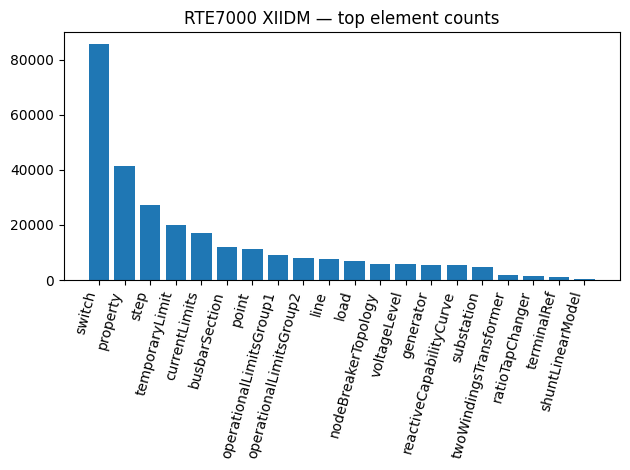

In [8]:
tags_df = pd.DataFrame(report["counts"]["tags_top40"])
display(tags_df)

counts_dict = {r["tag"]: r["count"] for r in report["counts"]["tags_top40"]}
bar_counts(counts_dict, title="RTE7000 XIIDM — top element counts", top_n=20)

* Topology is **Node-Breaker**, which explains extremely high `switch` counts.
* Key scale from output:

  * `substation = 4,811`
  * `voltageLevel = 5,867`
  * `nodeBreakerTopology = 5,867` (one per voltage level)
  * `switch = 85,704` (node-breaker representation)
  * `busbarSection = 11,864`
  * `line = 7,745`
  * `twoWindingsTransformer = 1,773`
  * `load = 6,876`, `generator = 5,625`
* Counts are **XML element occurrences**, not necessarily “unique electrical components” as seen in bus-breaker models.

---
#### Structural "tag paths" (prefix depth=3)

In [9]:
paths_df = pd.DataFrame(report["counts"]["tag_paths_top50"])
paths_df

,path,count
0,network/substation/voltageLevel,161707
1,network/substation/twoWindingsTransformer,41200
2,network/line/operationalLimitsGroup1,25375
3,network/line/operationalLimitsGroup2,21097
4,network/substation/property,9622
5,network/line,7745
6,network/line/property,7737
7,network/substation,4811
8,network/extension,2
9,network/extension/activePowerControl,2


* Shows where elements live in the XML tree (useful for debugging structure).
* Example interpretation:

  * `network/substation/voltageLevel = 161,707` reflects **nested elements under voltage levels**, not 161k voltage levels.
  * Transformer paths are large because each transformer carries nested tap changers, terminals, and limits.

---
#### ID counts + topologyKind distribution

In [10]:
ids = report["ids"]
topo = pd.DataFrame(report["topology"]["voltageLevel_topologyKind_counts"])
ids, topo

({'substations': 4811, 'voltageLevels': 5867, 'connectables': 22478},
    topologyKind  count
 0  NODE_BREAKER   5867)

* Distinguishes **unique IDs** from raw XML counts:

  * Unique `substations = 4,811`
  * Unique `voltageLevels = 5,867`
  * Unique `connectables = 22,478` (equipment that can connect via terminals)
* All voltage levels are reported as `NODE_BREAKER`, so connectivity must be derived from **nodes + switches** (not explicit buses).

---
#### Core sanity checks summary

In [11]:
checks = report.get("checks", {})

ref = checks.get("reference_resolution", {})
ctx = checks.get("contextual_containment", {})
num = checks.get("numeric_parsing", {})

summary = {
    "substationId_refs_total": ref.get("substationId", {}).get("refs_total", 0),
    "substationId_unresolved": ref.get("substationId", {}).get("unresolved_count", 0),
    "voltageLevelId_refs_total": ref.get("voltageLevelId", {}).get("refs_total", 0),
    "voltageLevelId_unresolved": ref.get("voltageLevelId", {}).get("unresolved_count", 0),
    "terminalRef_connectable_refs_total": ref.get("terminalRef_connectableId", {}).get("refs_total", 0),
    "terminalRef_connectable_unresolved": ref.get("terminalRef_connectableId", {}).get("unresolved_count", 0),
    "unexpected_context_violations": ctx.get("violations_count", 0),
    "numeric_parse_errors": num.get("errors_count", 0),
}

s = pd.Series(summary, dtype="int64")
display(s)

# Optional: only show examples when non-zero
if summary["unexpected_context_violations"] > 0:
    display(pd.DataFrame(ctx.get("violation_examples", [])))


substationId_refs_total                   0
substationId_unresolved                   0
voltageLevelId_refs_total             19036
voltageLevelId_unresolved                 0
terminalRef_connectable_refs_total        0
terminalRef_connectable_unresolved        0
unexpected_context_violations         10967
numeric_parse_errors                      0
dtype: int64

,tag,id,substation_ctx,voltageLevel_ctx
0,twoWindingsTransformer,ARGIAY771,ARGIA,None
1,twoWindingsTransformer,ARGIAY761,ARGIA,None
2,ratioTapChanger,,ARGIA,None
3,twoWindingsTransformer,ARGIAY711,ARGIA,None
4,twoWindingsTransformer,ARGIAY772,ARGIA,None
5,twoWindingsTransformer,ARGIAY762,ARGIA,None
6,ratioTapChanger,,ARGIA,None
7,twoWindingsTransformer,ARGIAY712,ARGIA,None
8,twoWindingsTransformer,ARGIAY631,ARGIA,None
9,ratioTapChanger,,ARGIA,None


* Reference-resolution is clean where measured:

  * `voltageLevelId_refs_total = 19,036`, unresolved = **0**
* Numeric parsing is clean:

  * `numeric_parse_errors = 0`
* Contextual containment flags a large number of “violations”:

  * `unexpected_context_violations = 10,967`
* The example table shows the pattern: elements have `substation_ctx` but `voltageLevel_ctx = None`.

  * This is a **parser/containment expectation mismatch** for some nested IIDM constructs (common in node-breaker exports), not a missing reference like “ID not found”.

---
#### Unresolved reference examples

In [12]:
# Unresolved reference examples (robust to missing keys)
ref = report.get("checks", {}).get("reference_resolution", {})

unres_sub = ref.get("substationId", {}).get("unresolved_examples", [])
unres_vl  = ref.get("voltageLevelId", {}).get("unresolved_examples", [])
unres_term = ref.get("terminalRef_connectableId", {}).get("unresolved_examples", [])

display(pd.DataFrame(unres_sub, columns=["tag", "id", "attr", "ref"]).head(20))
display(pd.DataFrame(unres_vl,  columns=["tag", "id", "attr", "ref"]).head(20))
display(pd.DataFrame(unres_term, columns=["terminalRefId", "attr", "connectableId"]).head(20))

,tag,id,attr,ref


,tag,id,attr,ref


,terminalRefId,attr,connectableId


---
#### Samples: substations + voltageLevels

In [13]:
substations = pd.DataFrame(report["samples"].get("substation", []))
vls = pd.DataFrame(report["samples"].get("voltageLevel", []))

display(substations)
display(vls)

,id,country,tso
0,.CTLH,FR,RTE
1,.CTLO,FR,RTE
2,.G.RO,FR,RTE
3,.NAVA,FR,RTE
4,0FORT,FR,RTE
5,0NOVI,FR,RTE
6,0PERR,FR,RTE
7,0R.LE,FR,RTE
8,0TREG,FR,RTE
9,ARGIA,FR,RTE


,id,nominalV,topologyKind,lowVoltageLimit,highVoltageLimit,fictitious
0,.CTLHP3,63.0,NODE_BREAKER,60.0,68.0,None
1,.CTLOP3,63.0,NODE_BREAKER,60.0,68.0,None
2,.G.ROP5,150.0,NODE_BREAKER,99.0,150.0,None
3,.G.ROP6,225.0,NODE_BREAKER,220.0,245.0,None
4,.NAVAP3,63.0,NODE_BREAKER,59.0,68.0,None
5,0FORTP3,63.0,NODE_BREAKER,59.0,68.0,None
6,0NOVIP3,63.0,NODE_BREAKER,59.0,68.0,None
7,0PERRP6,225.0,NODE_BREAKER,220.0,245.0,None
8,0R.LEP4,90.0,NODE_BREAKER,85.00000762939453,97.00000762939453,None
9,0TREGP3,63.0,NODE_BREAKER,59.0,68.0,None


* The samples confirm this is an **RTE (France)** dataset (`country=FR`, `tso=RTE`) and illustrate the substation ID naming convention (mixed alphanumerics, often prefixed with `.`).
* Voltage levels show the network is **multi-voltage** (examples include **63 kV, 150 kV, 225 kV**) and every sampled VL is **`NODE_BREAKER`**.
* `lowVoltageLimit` / `highVoltageLimit` are present in the voltageLevel elements, so voltage bounds exist at the voltage-level layer (not just equipment limits).
* These are **samples only** (`samples_per_tag`), shown to demonstrate structure and typical attribute presence—not to summarize the full distribution.

---
#### Samples: node-breaker primitives (busbarSection, switch)

In [14]:
bbs = pd.DataFrame(report["samples"].get("busbarSection", []))
sw = pd.DataFrame(report["samples"].get("switch", []))

display(bbs)
display(sw)

,id,name,node,substationId,voltageLevelId
0,.CTLHP3_1.1,1.1,0,.CTLH,.CTLHP3
1,.CTLHP3_1.2,1.2,1,.CTLH,.CTLHP3
2,.CTLOP3_1.1,1.1,0,.CTLO,.CTLOP3
3,.CTLOP3_1.2,1.2,1,.CTLO,.CTLOP3
4,.CTLOP3_1.3,1.3,2,.CTLO,.CTLOP3
5,.CTLOP3_2A,2A,3,.CTLO,.CTLOP3
6,.CTLOP3_2B1,2B1,4,.CTLO,.CTLOP3
7,.CTLOP3_2B2,2B2,5,.CTLO,.CTLOP3
8,.G.ROP5_1,1,0,.G.RO,.G.ROP5
9,.G.ROP6_1,1,0,.G.RO,.G.ROP6


,id,name,kind,open,retained,fictitious,node1,node2,substationId,voltageLevelId
0,.CTLHP3_.CTLH3SE.1.12SS.1.12F,.CTLH3SE.1.12SS.1.12F,DISCONNECTOR,true,false,true,0,1,.CTLH,.CTLHP3
1,.CTLHP3_.CTLH3.CTLO.1SA.1F,.CTLH3.CTLO.1SA.1F,DISCONNECTOR,false,false,true,0,2,.CTLH,.CTLHP3
2,.CTLHP3_.CTLH3.CTLH.1SA.1F,.CTLH3.CTLH.1SA.1F,DISCONNECTOR,false,false,true,0,6,.CTLH,.CTLHP3
3,.CTLHP3_.CTLH3.CTLH.2SA.1F,.CTLH3.CTLH.2SA.1F,DISCONNECTOR,false,false,true,1,8,.CTLH,.CTLHP3
4,.CTLHP3_.CTLH3.CTLO.2SA.1F,.CTLH3.CTLO.2SA.1F,DISCONNECTOR,false,false,true,1,4,.CTLH,.CTLHP3
5,.CTLHP3_.CTLH3.CTLO.1DJF,.CTLH3.CTLO.1DJF,BREAKER,false,false,true,2,3,.CTLH,.CTLHP3
6,.CTLHP3_.CTLH3.CTLO.2DJF,.CTLH3.CTLO.2DJF,BREAKER,false,false,true,4,5,.CTLH,.CTLHP3
7,.CTLHP3_.CTLH3.CTLH.1DJF,.CTLH3.CTLH.1DJF,DISCONNECTOR,false,false,true,6,7,.CTLH,.CTLHP3
8,.CTLHP3_.CTLH3.CTLH.2DJF,.CTLH3.CTLH.2DJF,DISCONNECTOR,false,false,true,8,9,.CTLH,.CTLHP3
9,.CTLOP3_.CTLO3FINS .1SA.1F,.CTLO3FINS .1SA.1F,DISCONNECTOR,false,false,true,0,20,.CTLO,.CTLOP3


* `busbarSection` ties a named busbar segment (e.g., `1.1`, `1.2`) to a **node index** inside a voltage level (`node`), and is anchored via `(substationId, voltageLevelId)`.
* `switch` provides the actual **node-breaker connectivity** via `(node1, node2)` plus state (`open`) and category (`kind`).
* Practical meaning: connectivity reconstruction in this dataset is driven by **nodes + switches**, not by explicit “bus” objects.

---
#### Samples: injections (load, generator)

In [15]:
loads = pd.DataFrame(report["samples"].get("load", []))
gens = pd.DataFrame(report["samples"].get("generator", []))

display(loads)
display(gens)

,id,loadType,node,substationId,voltageLevelId
0,.CTLO3.CTLO-Y311,UNDEFINED,7,.CTLO,.CTLOP3
1,.CTLO3.CTLO-Y312,UNDEFINED,9,.CTLO,.CTLOP3
2,.CTLO3.CHEV,UNDEFINED,11,.CTLO,.CTLOP3
3,.CTLO3.CORN,UNDEFINED,13,.CTLO,.CTLOP3
4,.CTLO3.LOCL,UNDEFINED,25,.CTLO,.CTLOP3
5,.CTLO3.NUMA,UNDEFINED,27,.CTLO,.CTLOP3
6,.G.RO5FEDA,UNDEFINED,2,.G.RO,.G.ROP5
7,.G.RO6FEDA,UNDEFINED,2,.G.RO,.G.ROP6
8,.NAVA3IE,UNDEFINED,2,.NAVA,.NAVAP3
9,ARGIA3CD1,UNDEFINED,10,ARGIA,ARGIAP3


,id,energySource,minP,maxP,voltageRegulatorOn,node,substationId,voltageLevelId
0,.CTLO3GROUP.1,HYDRO,0.0,15.0,true,7,.CTLH,.CTLHP3
1,.CTLO3GROUP.2,HYDRO,0.0,15.0,true,9,.CTLH,.CTLHP3
2,ARGIAINF,SOLAR,0.0,0.699999988079071,false,18,ARGIA,ARGIAP3
3,ARGOEIN2,WIND,0.0,0.0,false,24,ARGOE,ARGOEP4
4,ARGOEIN3,WIND,0.0,14.399999618530273,false,28,ARGOE,ARGOEP4
5,ARGOEINF,SOLAR,0.0,0.30000001192092896,false,39,ARGOE,ARGOEP4
6,ARGOEING,SOLAR,0.0,0.30000001192092896,false,40,ARGOE,ARGOEP4
7,ARGOEIN1,WIND,0.0,42.599998474121094,false,24,ARGOE,ARGOEP6
8,B.CARINF,SOLAR,0.0,2.0999999046325684,false,24,B.CAR,B.CARP6
9,EGUZO4EGUZOH1+2+3,HYDRO,0.0,35.279998779296875,true,9,EGUZO,EGUZOP4


* `load` elements appear primarily as **connectable placeholders**:

  * visible fields: `id`, `loadType`, `node`, plus resolved context `(substationId, voltageLevelId)`.
  * sample shows `loadType=UNDEFINED` frequently.
* `generator` elements expose **capability metadata**:

  * `energySource`, `minP`, `maxP`, `voltageRegulatorOn`, and placement `node`.
* Net result: this snapshot is equipment-structured and contains generator capability bounds, while loads here do not show operating-point injections.

---
#### Samples: branches (line, transformer, danglingLine, SVC)

In [16]:
lines = pd.DataFrame(report["samples"].get("line", []))
trafos = pd.DataFrame(report["samples"].get("twoWindingsTransformer", []))
dang = pd.DataFrame(report["samples"].get("danglingLine", []))
svc = pd.DataFrame(report["samples"].get("staticVarCompensator", []))

display(lines)
display(trafos)
display(dang)
display(svc)

,id,r,x,g1,b1,g2,b2,voltageLevelId1,node1,voltageLevelId2,node2,substationId,voltageLevelId
0,.CTLHL31.CTLO,1.1493520736694336,2.103874921798706,0.0,6.000000212225132E-6,0.0,6.000000212225132E-6,.CTLHP3,3,.CTLOP3,17,None,None
1,.CTLHL32.CTLO,1.1493520736694336,2.103874921798706,0.0,6.000000212225132E-6,0.0,6.000000212225132E-6,.CTLHP3,5,.CTLOP3,19,None,None
2,.CTLOL31FINS,2.127000093460083,4.709000110626221,0.0,1.700000029813964E-5,0.0,4.5000000682193786E-5,.CTLOP3,21,FINS P3,3,None,None
3,.CTLOL31ZLIEB,3.869999885559082,9.045000076293945,0.0,3.2000003557186574E-5,0.0,3.300000025774352E-5,.CTLOP3,31,ZLIEBP3,4,None,None
4,.G.ROL51HOSPI,1.599000096321106,4.665998935699463,0.0,3.23410022247117E-5,0.0,2.7764999686041847E-5,.G.ROP5,4,HOSPIP5,6,None,None
5,.G.ROL61HOSPI,0.4790000915527344,3.0929999351501465,0.0,2.443529956508428E-4,0.0,1.7879100050777197E-4,.G.ROP6,4,HOSPIP6,15,None,None
6,.NAVAL31SSDAL,3.799999475479126,10.80000114440918,0.0,3.400000059627928E-5,0.0,3.400000059627928E-5,.NAVAP3,4,SSDALP3,9,None,None
7,0FORTL31FORTA,0.012000000104308128,6.130000114440918,0.0,0.0,0.0,0.0,0FORTP3,2,FORTAP3,25,None,None
8,0FORTL32FORTA,0.012000000104308128,6.130000114440918,0.0,0.0,0.0,0.0,0FORTP3,4,FORTAP3,2,None,None
9,0NOVIL31NOVIO,0.010000000707805157,0.10000001639127731,0.0,1.0000001111620804E-6,0.0,1.0000001111620804E-6,0NOVIP3,2,NOVIOP3,51,None,None


,id,r,x,g,b,ratedU1,ratedU2,voltageLevelId1,node1,voltageLevelId2,node2,substationId,voltageLevelId
0,ARGIAY771,0.16999998688697815,42.399993896484375,0.0,0.0,380.0,380.0,ARGIAP7,3,1ARGIP7,2,ARGIA,None
1,ARGIAY761,0.3100000023841858,-6.799999713897705,0.0,0.0,225.0,380.0,ARGIAP6,7,1ARGIP7,4,ARGIA,None
2,ARGIAY711,4.889999866485596,124.69998168945312,0.0,0.0,20.0,380.0,ARGIAP1,3,1ARGIP7,6,ARGIA,None
3,ARGIAY772,0.23999997973442078,43.09999465942383,0.0,0.0,380.0,380.0,ARGIAP7,5,2ARGIP7,2,ARGIA,None
4,ARGIAY762,0.27999991178512573,-7.899999141693115,0.0,0.0,225.0,380.0,ARGIAP6,9,2ARGIP7,4,ARGIA,None
5,ARGIAY712,2.419999599456787,120.1999740600586,0.0,0.0,20.0,380.0,ARGIAP1,5,2ARGIP7,6,ARGIA,None
6,ARGIAY631,0.8699999451637268,62.20000457763672,0.0,0.0,63.0,225.0,ARGIAP3,13,ARGIAP6,19,ARGIA,None
7,ARGIAY632,0.6049999594688416,58.93000030517578,0.0,0.0,63.0,225.0,ARGIAP3,15,ARGIAP6,21,ARGIA,None
8,ARGOEY771,0.2800000011920929,55.09999465942383,0.0,0.0,380.0,380.0,ARGOEP7,7,1ARGOP7,2,ARGOE,None
9,ARGOEY761,0.20999830961227417,-16.0,0.0,0.0,225.0,380.0,ARGOEP6,9,1ARGOP7,4,ARGOE,None


,id,name,pairingKey,r,x,g,b,node,substationId,voltageLevelId
0,.ARKAL61ARGIA,FR_ES_.TDAR 6,,1.125,7.1504998207092285,0.0,5.1973998779430985E-5,5,ARGIA,ARGIAP6
1,.HERNL71ARGIA,FR_ES_.HERN 7,,0.7854998707771301,8.468999862670898,0.0,8.505800360580906E-5,11,ARGIA,ARGIAP7
2,.RIDDL61CORNI,FR_CH_.RIDD 6,,2.816500186920166,17.492502212524414,0.0,1.269999920623377E-4,21,CORNI,CORNIP6
3,.SSTRL61CORNI,FR_CH_.SSTR 6,,2.186000108718872,13.031999588012695,0.0,9.700000373413786E-5,23,CORNI,CORNIP6
4,.VERBL61GEN.P,FR_CH_.VERB 6,,0.6919999718666077,4.736999988555908,0.0,3.5000000934815034E-5,43,GEN.P,GEN.PP6
5,.VERBL62GEN.P,FR_CH_.VERB 6,,0.6915000081062317,4.734000205993652,0.0,3.5000000934815034E-5,45,GEN.P,GEN.PP6
6,.RODPL71ALBER,FR_IT_.TDRO 7,,1.5139998197555542,26.79050064086914,0.0,5.050000036135316E-4,27,ALBER,ALBERP7
7,.RODPL72ALBER,FR_IT_.TDRO 7,,1.5145001411437988,26.775497436523438,0.0,5.050000036135316E-4,29,ALBER,ALBERP7
8,.ASPHL71SIERE,FR_CH_.ASPH 7,,0.4650000333786011,4.545000076293945,0.0,6.70000008540228E-5,3,SIERE,SIEREP7
9,.BASSL71SIERE,FR_CH_.BASS 7,,0.6600000262260437,7.4549994468688965,0.0,7.999999797903001E-5,9,SIERE,SIEREP7


,id,node,p,q,bMin,bMax,regulationMode,voltageSetpoint,reactivePowerSetpoint,substationId,voltageLevelId
0,CSPDO.TC1,26,0.0,-12.07900333404541,-0.004938271827995777,0.004938271827995777,VOLTAGE,240.8320770263672,0.0,DOMLO,DOMLOP6
1,CSPCH.TC1,26,0.0,-34.71733474731445,-0.0019753086380660534,0.004938271827995777,VOLTAGE,238.8815460205078,0.0,CHEV5,CHEV5P6
2,CSPME.TC1,24,0.0,-19.894432067871094,-0.004938271827995777,0.004938271827995777,VOLTAGE,238.17210388183594,0.0,MERLA,MERLAP6
3,CSPNA.TC1,50,0.0,79.99823760986328,-0.0019753086380660534,0.003950617276132107,VOLTAGE,241.2665557861328,0.0,NANTE,NANTEP6
4,CSPPH.TC1,22,0.0,-46.23270034790039,-0.00148148147854954,0.00148148147854954,VOLTAGE,239.9592742919922,0.0,P.HA5,P.HA5P6
5,CSPPR6GR.PR,26,0.0,5.14989709854126,-0.00296296295709908,0.00296296295709908,VOLTAGE,237.71214294433594,0.0,P.ROU,P.ROUP6
6,CSPTO.TC1,22,0.0,-0.0,-0.0019753086380660534,0.004938271827995777,VOLTAGE,240.1382598876953,0.0,TOURB,TOURBP6


* `line` samples provide:

  * series parameters (`r`, `x`) and shunt terms (`g1/b1`, `g2/b2`)
  * endpoints using **node-breaker terminals**: `(voltageLevelId1, node1)` ↔ `(voltageLevelId2, node2)`
* `twoWindingsTransformer` samples provide:

  * impedance (`r`, `x`), shunt (`g`, `b`), and rated voltages (`ratedU1`, `ratedU2`)
  * endpoints via the same VL+node addressing as lines
  * note: some sampled `x` values appear negative, reflecting source-export conventions; do not assume sign constraints.
* `danglingLine` represents **boundary / external connections**:

  * `name` often encodes neighbor/zone hints (e.g., `FR_ES_…`, `FR_CH_…`, `FR_IT_…`)
  * `pairingKey` appears absent in the shown sample rows (blank/None), so pairing metadata is not guaranteed.
* `staticVarCompensator` samples show explicit voltage control configuration:

  * `regulationMode=VOLTAGE`
  * `voltageSetpoint` around the expected HV range (≈238–241 in the sample)
  * susceptance limits `bMin/bMax` present, `reactivePowerSetpoint` shown as 0.0 in the sample.

---
#### Attribute keys: demonstrate “no injections included” signal

In [17]:
attr_keys = report["attribute_keys"]

# what attributes exist for load / generator (evidence of whether P/Q are present)
{
    "load_attr_keys": attr_keys.get("load", []),
    "generator_attr_keys": attr_keys.get("generator", []),
}

{'load_attr_keys': ['id', 'loadType', 'node'],
 'generator_attr_keys': ['energySource',
  'id',
  'maxP',
  'minP',
  'node',
  'voltageRegulatorOn']}

* The attribute-key summary is the proof-of-structure cell:

  * `load_attr_keys = ['id', 'loadType', 'node']` → no `p/q` attributes present on loads in this snapshot.
  * `generator_attr_keys` includes `minP/maxP`, `energySource`, `voltageRegulatorOn` → generator capability/regulation metadata is present.
* This cell establishes what can be relied on **without scanning samples**.

---
#### Numeric parse errors (if any)

In [18]:
err = report["checks"]["numeric_parsing"]["error_examples"]
pd.DataFrame(err).head(50)

""
